<center>  

# Neural computation - Workgroup Assignment 1
<br/>
<br/>
    
<center>
Radboud University


<center>
September 2024


<center>
Sander Keemink
    



## Instructions
To finish this assignment, answer the below questions *in this notebook*, and upload the result on brightspace as your assignment submission. You can do this as the notebook, pdf export, or html export (the last two would make life easier for the TAs if you use a non-standard plotting library for example). Clearly indicate your own additions to the notebook. 

You can work together, but do not copy each other's code -- this is considered plagiarism!

When asked to mathematically show something, use latex to show the steps.

When asked to plot something, use the plotting toolbox of your choice to do so. (we took the liberty of importing matplotlib)

Topics 1-3 (and half today's grade) are meant to give you some practice with the core skills required. The final topic (the other half of the grade) will take more time, and is the core assignment.

### Basic imports

In [22]:
import math

# the only two python modules you will need for this tutorial are numpy and matplotlib
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
%matplotlib inline

### Topic 1: Linear 1D system and fixed points (0.5 points)
Consider the following system

$\dot{r} = f(r)$

$f(r) = (w-1)r+I.$

(as a reminder, $\dot{r}$ is short hand for $\frac{dr}{dt}$)

(A) For $w=-0.5$ and $I=0$ plot the derivative as a function of $r$. Mathematically show what the fixed point is, and determine its stability. (0.25 points)

(B) Do the same for $w = 1.5$ and $I=-2$. (0.25 points)


### Question A
First off we need to find the fixed point, which is done by setting the funciton to zero.

$f(r) = (-0.5 -1)r + 0$

$f(r) = -1.5r$

$-1.5r = 0$

$r=0$

So the fixed point is $r=0$. Now to see if its stable we must study the sign of the first derivative, to see the slope direction.

$\dot{r}= -1.5$

Since the first derivative is less than zero, the fixed poiint is considered stable, meaning that if the funciont lands to a value similar to it, it will tend to go towards the fixed point value.

### Question B
Similar as to question A

$f(r)= (1.5 - 1)r - 2$

$f(r) = 0.5r - 2$

$0.5r -2 = 0$

$r = 4$ (fixed point)

$\dot{r} = 0.5 $ (unstable)

### Topic 2: Integration methods (1 point)
Many differential equations are hard to solve analytically, but are fairly easy to simulate through step-wise integration methods. In this exercise we will explore these.

The Euler method is the simplest and surprisingly effective (https://en.wikipedia.org/wiki/Euler_method). We have implemented it for you below:

In [23]:
# a simple euler-solver
def euler_solve(f, x0, par, dt, nT):
    '''Simulates the system of differential equations specified by dx/dt = f(x, par), using forward Euler.
    
    Dimensioality of system will below be given by K. (i.e. for 2D systems K=2)
    
    Parameters
    ----------
    f : function
        Function of form f(x, par). Should output array of length K.
    x0 : array, shape
        Starting values. Should be list or array of length K.
    par : unknown
        Whatever parameters go into f (can be single variable, or a list, etc.)
    dt : float
        Timestep size
    nT : int
        Number of timesteps
    
    Output
    ------
    array
        Simulated values, of shape (K, nT).
    '''
    # preamble
    nS = len(x0) # nr of equations/signals
    xs = np.zeros((nS, nT)) # predefined output
    xs[:, 0] = x0
    
    # loop over time
    for i in range(nT-1):
        xs[:, i+1] = xs[:, i] + dt*f(xs[:, i], par)
    
    # return
    return xs

#### Example implementation for $\dot{r} = -sr$

In [24]:
# Parameters
s = 1
par = [s]
f = lambda x, par: -par[0]*x
r0 = np.array([1])
dt = 1e-2
nT = 100

# simulate
r_simulated = euler_solve(f, r0, par, dt, nT)


#### Questions
(A) Use the Euler method to solve the systems from topic 1A and confirm your fixed-point predictions. (0.5 points)

(B) Implement similar solvers for the improved Euler method (https://en.wikipedia.org/wiki/Heun's_method) and the fourth-order Runge-Kutta method (https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods). Note that our functions have no explicit time dependence. The analytical solution to the differential equation is $r(t) = r_0 e^{(w-1) t}$. For different timesteps, compare how well each method (Euler, improved Euler, and Runge-Kutta) matches the analytical solution. (0.5 points)

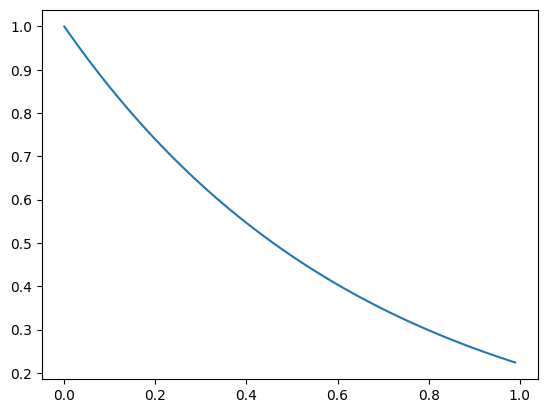

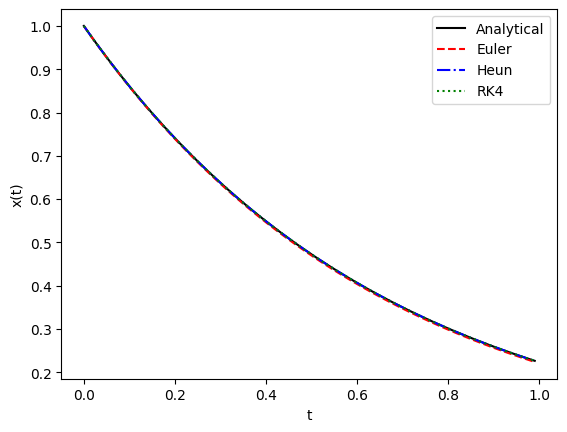

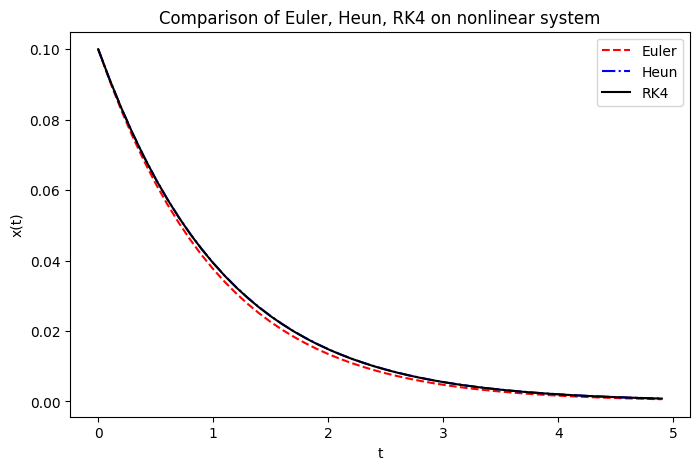

In [25]:
### A
# Parameters
s = 1
par = [1.5]
f = lambda x, par: -par[0]*x
r0 = np.array([1])
dt = 1e-2
nT = 100

# Euler solver
xs_euler = euler_solve(f, r0, par, dt, nT)

r0 = np.array([0.0])  #this is so we can start the simulation at the fixed point and we can see how it behaves
t = np.arange(nT)*dt
plt.plot(t, xs_euler[0])
plt.show() #stable at fixed point

### B

def heun_solve(f, x0, par, dt, nT):
    '''Simulates the system of differential equations specified by dx/dt = f(x, par), using forward Euler.

    Dimensioality of system will below be given by K. (i.e. for 2D systems K=2)

    Parameters
    ----------
    f : function
        Function of form f(x, par). Should output array of length K.
    x0 : array, shape
        Starting values. Should be list or array of length K.
    par : unknown
        Whatever parameters go into f (can be single variable, or a list, etc.)
    dt : float
        Timestep size
    nT : int
        Number of timesteps

    Output
    ------
    array
        Simulated values, of shape (K, nT).
    '''
    # preamble
    nS = len(x0) # nr of equations/signals
    xs = np.zeros((nS, nT)) # predefined output
    xs[:, 0] = x0

    # loop over time
    for i in range(nT-1):
        x_predict = xs[:, i] + dt * f(xs[:, i], par)
        xs[:, i+1] = xs[:, i] + dt/2*(f(xs[:, i], par)+ f(x_predict, par))
    # return
    return xs

def rk4_solve(f, x0, par, dt, nT):
    '''Simulates the system of differential equations specified by dx/dt = f(x, par), using forward Euler.

    Dimensioality of system will below be given by K. (i.e. for 2D systems K=2)

    Parameters
    ----------
    f : function
        Function of form f(x, par). Should output array of length K.
    x0 : array, shape
        Starting values. Should be list or array of length K.
    par : unknown
        Whatever parameters go into f (can be single variable, or a list, etc.)
    dt : float
        Timestep size
    nT : int
        Number of timesteps

    Output
    ------
    array
        Simulated values, of shape (K, nT).
    '''
    # preamble
    nS = len(x0) # nr of equations/signals
    xs = np.zeros((nS, nT)) # predefined output
    xs[:, 0] = x0

    # loop over time
    for i in range(nT-1):
        k1 = dt*f(xs[:, i], par)
        k2 = dt*f(xs[:, i] + k1/2, par)
        k3 = dt*f(xs[:, i] + k2/2, par)
        k4 = dt*f(xs[:, i] + k3, par)
        xs[:, i+1] = xs[:, i] + 1/6*(k1 + 2*k2 + 2*k3 + k4)
    # return
    return xs

r0 = np.array([1])
xs_euler = euler_solve(f, r0, par, dt, nT)
xs_heun = heun_solve(f, r0, par, dt, nT)
xs_rk4 = rk4_solve(f, r0, par, dt, nT)

analytical = lambda t, r0: r0*np.e**(-par[0]*t)
t = np.arange(nT) * dt
x_analytical = analytical(t, r0[0])

#visualize them, plotting each xs against the analytiical solution
plt.plot(t, x_analytical, 'k-', label='Analytical')
plt.plot(t, xs_euler[0], 'r--', label='Euler')
plt.plot(t, xs_heun[0], 'b-.', label='Heun')
plt.plot(t, xs_rk4[0], 'g:', label='RK4')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.legend()
plt.show()

#these look pretty accurate to the analytical solution, we can try a more complex function to see if the differences in accuracy are more evident
# looking through internet i got reccomended a non-linear function, ex. x^2-x. we can use rk4, the most accurate, as a substitute for it, as a point of comparison
par = []
f = lambda x, par: x**2 - x

r0 = np.array([0.1])
dt = 0.1              # larger dt to exaggerate differences
nT = 50
t = np.arange(nT) * dt


xs_euler = euler_solve(f, r0, par, dt, nT)
xs_heun = heun_solve(f, r0, par, dt, nT)
xs_rk4 = rk4_solve(f, r0, par, dt, nT)


plt.figure(figsize=(8,5))
plt.plot(t, xs_euler[0], 'r--', label='Euler')
plt.plot(t, xs_heun[0], 'b-.', label='Heun')
plt.plot(t, xs_rk4[0], 'k-', label='RK4')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Comparison of Euler, Heun, RK4 on nonlinear system')
plt.legend()
plt.show()

#herrer you can see better that there is some difference between Euler's results and the other two, which are more accurate.

### Topic 3: Linear 2D systems (1.5 points)

We provide below a function for plotting phaseplanes and nullclines.


In [26]:
def phaseplane_2D(f, par, xs_nullclines, xs_quiver=None, add_vectors=False, labels=['x1', 'x2']):
    '''Plots the phaseplane in 2D.
    
    Parameters
    ----------
    f : function
        Derivative function, of form f(x, par)
    par : unknown
        Whatever parameters the f function needs
    xs_nullclines : array
        Values at which calculate hte nullclines
    xs_quiver : array
        Values at which to plot the derivative vectors (only necessary if add_vectors is True)
    add_vectors : bool, true by default
        Whether to plot the vector fields
    labels : list of strings
        Optional axis name changes (default: ['x1', 'x2'])
    '''
    # first calculate nullclines
    # get number of grid points
    n_grid = len(xs_nullclines)
    
    # derivatives at each of the points
    x1_grid = np.array([[x1 for x1 in xs_nullclines] for x2 in xs_nullclines])
    x2_grid = np.array([[x2 for x1 in xs_nullclines] for x2 in xs_nullclines])
    f_grid = np.array([[f(np.array([x1, x2]), par) for x1 in xs_nullclines] for x2 in xs_nullclines])

    # plot nullclines
    plt.contour(x1_grid, x2_grid, f_grid[:, :, 0], 0, colors='r')
    plt.contour(x1_grid, x2_grid, f_grid[:, :, 1], 0, colors='b')
    
    # then plot quivers
    if add_vectors:
        # get number of grid point
        n_grid = len(xs_quiver)

        # derivatives at each of the points
        x1_grid = np.array([[x1 for x1 in xs_quiver] for x2 in xs_quiver])
        x2_grid = np.array([[x2 for x1 in xs_quiver] for x2 in xs_quiver])
        f_grid = np.array([[f(np.array([x1, x2]), par) for x1 in xs_quiver] for x2 in xs_quiver])
        
        U, V = f_grid[:, :, 0], f_grid[:, :, 1]
        plt.quiver(xs_quiver, xs_quiver, U, V)
    
    # add labels
    plt.xlabel(labels[0], fontsize=14)
    plt.ylabel(labels[1], fontsize=14)

Consider the following 2D system

$\dot{\mathbf r} = \mathbf A \mathbf r,$

where $\mathbf r = [r_1, r_2]^\top$, and $\mathbf A = \begin{bmatrix}
a & b \\ 
c & d
\end{bmatrix}$.

Here is an example implementation of the ```phaseplane_2D``` function for $\mathbf A = \begin{bmatrix}
-1 & 0 \\ 
0 & -1
\end{bmatrix}$.


<function matplotlib.pyplot.show(close=None, block=None)>

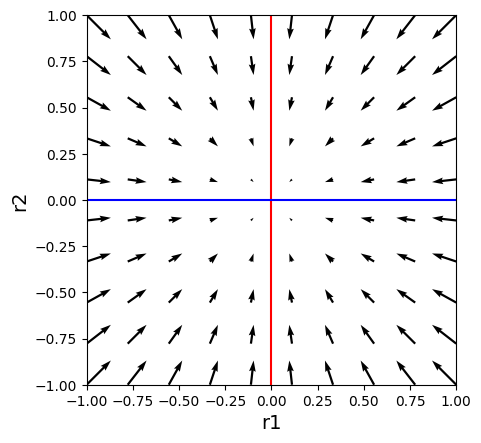

In [27]:
# Parameters
a = -1
b = 0
c = 0
d = -1
A = np.array([[a, b], [c, d]])

# group parameters
par = [A]

# differential equation
f = lambda r, par: par[0]@r

# plot phase plane
n_grid_quiver = 10 # how many points to sample for vector field
rs_quiver = np.linspace(-1, 1, n_grid_quiver)

n_grid_nullclines = 100 # how many points to sample for finding nullclines
rs_nullclines = np.linspace(-1, 1, n_grid_nullclines)

# plot phaseplot
phaseplane_2D(f, par, rs_nullclines, rs_quiver, add_vectors=True, labels=['r1', 'r2'])
plt.axis('scaled')
plt.show

#### Questions

We have shared a link to the Dynamical Systems in Neuroscience textbook on brightspace. Study chapters 4.2.2-4.2.5.


(A) For $\mathbf A = \begin{bmatrix}
-2 & 0 \\
0 & 3
\end{bmatrix}$ find the fixed point, the local eigenvalues, and eigenvectors. Based on those, classify the fixed point. If done numerically with e.g. np.linalg.eig(), get half points, if done mathematically, get full points. (0.5 points)

(B) Same as (A), but for $\mathbf A = \begin{bmatrix}
-1 & -2 \\
2 & -3
\end{bmatrix}$. (0.5 points)

(C) Using the provided ```phaseplane_2D()``` function, plot the phase planes for the systems from A+B. Simulate the systems from A+B, and confirm your predictions from A+B. (0.5 points)



#### Question (A)
Calculate fixed point:
$\dot{\mathbf r} = A*r$
since the determinant $a*d - b*c \neq 0$ then we only have one solutioin, which is the trivial solution of $r = 0$. This means the fixed point is at the origin.

Calculate eigenvalues:

p$(\lambda) = det(M - \lambda*I)$

the determinant for this is once again zero, so we can use the terms to find the two eigenvalues:
$\mathbf p = \begin{bmatrix}
-2-\lambda & 0 \\
0 & 3-\lambda
\end{bmatrix}$

$-2-\lambda = 0$, $\lambda = -2$

$3- \lambda = 0$, $\lambda = 3$

Calculate eigenvectors:
We need to do $(M - \lambda*I)*v$

for $\lambda = -2$

$\mathbf A = \begin{bmatrix}
-2+2 & 0 \\
0 & 3+2
\end{bmatrix}$

Which results in $v = [0,5]$, which simplified would be $v = [0,1]$

for $\lambda = 3$

$\mathbf A = \begin{bmatrix}
-2-3 & 0 \\
0 & 3-3
\end{bmatrix}$

Which results in $v = [-5, 0]$ which simplified would be $v = [1, 0]$

Now by looking at the results, seeing as the two eigenvalues are rea-valued and have opposite signs, we can say the equilibrium at the origin is a saddle, which is unstable by definition. The trajectories will be approaching the origin through the stable vector, the one that corresponds to $\lambda=-2$, and getting out from the unstable one.



<function matplotlib.pyplot.show(close=None, block=None)>

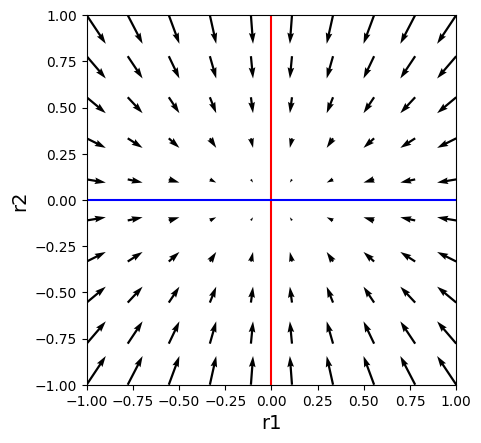

In [33]:
# Parameters
a = -2
b = 0
c = 0
d = -3
A = np.array([[a, b], [c, d]])

# group parameters
par = [A]

# differential equation
f = lambda r, par: par[0]@r

# plot phase plane
n_grid_quiver = 10 # how many points to sample for vector field
rs_quiver = np.linspace(-1, 1, n_grid_quiver)

n_grid_nullclines = 100 # how many points to sample for finding nullclines
rs_nullclines = np.linspace(-1, 1, n_grid_nullclines)

# plot phaseplot
phaseplane_2D(f, par, rs_nullclines, rs_quiver, add_vectors=True, labels=['r1', 'r2'])
plt.axis('scaled')
plt.show

#### Question (B)
Calculate fixed point:
$\dot{\mathbf r} = A*r$
since the determinant $a*d - b*c \neq 0$ then we only have one solutioin, which is the trivial solution of $r = 0$. This means the fixed point is at the origin.

Calculate eigenvalues:

p$(\lambda) = det(M - \lambda*I)$

the determinant for this is once again zero, so we can use the terms to find the two eigenvalues:
$\mathbf p = \begin{bmatrix}
-1-\lambda & -2 \\
2 & -3-\lambda
\end{bmatrix}$

we do the determinant to find the characteristic polynomial: $\lambda^{2} + 4\lambda +7$

 $\lambda = -2+ i \sqrt{3} $

 $\lambda = -2 - i \sqrt{3} $

Calculate eigenvectors:
We need to do $(M - \lambda*I)*v$

for $\lambda = -2+ i \sqrt{3} $

$\mathbf A = \begin{bmatrix}
-1-(-2+ i\sqrt{3}) & -1 \\
2 & 3-(-2+ i\sqrt{3})
\end{bmatrix}$

Which results in $v = [1,\frac{1-i\sqrt{3}}{2}]$

for $\lambda = -2 - i\sqrt{3}$

$\mathbf A = \begin{bmatrix}
-1-(-2- i\sqrt{3}) & -1 \\
2 & 3-(-2- i\sqrt{3})
\end{bmatrix}$


Which results in $v = [1,\frac{1+i\sqrt{3}}{2}]$

Now by looking at the results, seeing as the two eigenvalues are complex-valued  we have a spiral towards the origin with an amplitude decay at the rate of $e^{-2t}$. The oscillatory frequency is given by the imaginary part, so $\omega = \sqrt{3}$.



<function matplotlib.pyplot.show(close=None, block=None)>

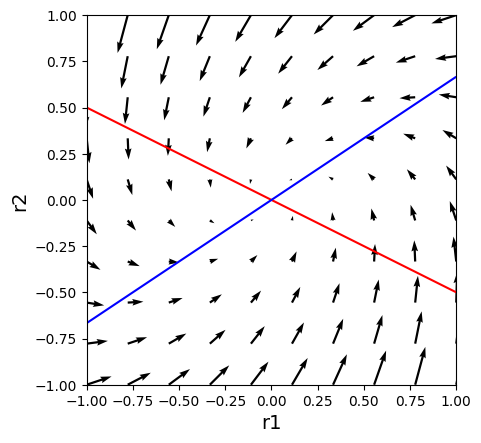

In [34]:
# Parameters
a = -1
b = -2
c = 2
d = -3
A = np.array([[a, b], [c, d]])

# group parameters
par = [A]

# differential equation
f = lambda r, par: par[0]@r

# plot phase plane
n_grid_quiver = 10 # how many points to sample for vector field
rs_quiver = np.linspace(-1, 1, n_grid_quiver)

n_grid_nullclines = 100 # how many points to sample for finding nullclines
rs_nullclines = np.linspace(-1, 1, n_grid_nullclines)

# plot phaseplot
phaseplane_2D(f, par, rs_nullclines, rs_quiver, add_vectors=True, labels=['r1', 'r2'])
plt.axis('scaled')
plt.show

### Topic 4: Investigating binary decision making (3 points)

### Introduction
Consider the following stimulus: https://www.youtube.com/watch?v=aNDlsynK7tk


This is a random dot kinematogram which is widely used to study decision making. An experimenter would then for example ask 'Are the dots moving, on average, to the left or the right?'. Generally a random dot kinematrogram is built up of dots moving in random directions, plus a percentage (the 'coherence') of dots moving in the same direction, as follows:


<center><img src='./random_dot_explanation.png' width=600>
    (Figure from Heins et al, 2020)
    
A widely used model for this is similar to the Wilson-Cowan models we also saw in the lectures. One can show that a highly complicated and large network of 7200 spiking neurons can be reduced to the interations of just two variables (Wong & Wang (2006) J. of Neuroscience). The resulting model is still quite complicated, so below we will use a further simplified and dimensionless model which acts qualitatively similarly.


### The model
    
The simplified models corresponds to two populations of neurons which excite themselves, and inhibit each other. Their dynamical system looks as follows:

$\dot{\mathbf r} =  -\mathbf r + g(\mathbf W \mathbf r + I_{bg} + \mathbf I_\text{stim})$

$g(x) = \frac{1}{1 + e^{-x}},$

where $\mathbf r=[r_1, r_2]^\top$ are the neural activities, $\mathbf W = \begin{bmatrix}
3 & -5 \\ 
-5 & 3
\end{bmatrix}$ defines the self and recurrent connectivity, $I_\text{bg} = -2$ is a shared background input, and $\mathbf I_\text{stim} = [I_1, I_2]^\top$ gives the individual inputs into each cell. The resulting network is illustrated below:

       
<center><img src='neural systems - exc-inh pair.svg' width=400>
    
    
   
The goal of the resulting model is that each neuron is matched to a stimulus direction, and its activity should 'win' over the activity of the other neuron. So if neuron 1 receives more input (corresponding e.g. to more rightward motion) the network dynamics should be such that neuron 1 gets a much higher activity than neuron 2. The theory is then that if neuron 1 has higher activity, the model 'perceives' direction 1, and vice versa.
    
The input coherence ($C$) can vary from -100% to 100% (corresponding to 100% leftward or 100% rightward motion). When the coherence $C$ is 0%, the net motion is the same, and both neurons should receive equal input. If the coherence is larger or smaller than 0%, one of the neurons should receive more input.
  
As such the individual inputs are set as follows:
    
$ I_1 = 3*(1-C/100) $ 
    
$ I_2 = 3*(1+C/100) $
    
These inputs only turn on when there is a stimulus.

#### Questions
Implement the above model, and answer the below questions. Note that (G) might be the toughest one -- but it also gives a lot of points.

(A) In absence of a stimulus, what does the phase plot look like? What do you predict about the activity of the two neurons? Confirm with a simulation. (0.5 points)

I would say that the neurons' activity will tend to go towards zero, due to symmetry.

(B) If we turn on a stimulus with $C=0$%, what happens to the phase plot? What do you predict for the activity of the two neurons? Confirm with a simulation. (0.5 points)

It should depend on the initial conditions, but with C=0 the model does not deterministically prefer one neuron over the other.


(C) If we turn on a stimulus with more motion in one or the other direction, what happens to the phase plot? What do you predict for the activity of the two neurons? Confirm with a simulation. (0.25 points)

I can predict that the system is going to be skewed towards one side, with the loop of negative feedback the weaker stimulus is gonna get progressivilely more inhibited, while the other one is going to be progressively more excited.
 
(D) Given your studies in A-C, can you explain how this model functions as a decision making model? (0.5 points)
The two neurons compete with each other, when both get input, whichever one is slightly stronger suppresses the other through inhibition and ends up much more active. That “winner-take-all” behavior turns small differences in input (evidence) into a clear choice — high activity in one neuron means the model “decided” for that stimulus direction.

(E) If the coherence is 0%, what is the main driving factor for which direction the model 'perceives'? (0.25 points)
IT should be the initial conditions.

(F) What do you think would happen if significant noise is added to the system? (0.25 points)
It will introduce random fluctations so the system will go from being deterministic to being stochastic.

(G) Find and classify the fixed points in both the stimulus-off and stimulus-on conditions. (Recommended to do this numerically, analytically likely not possible) (0.75 points)



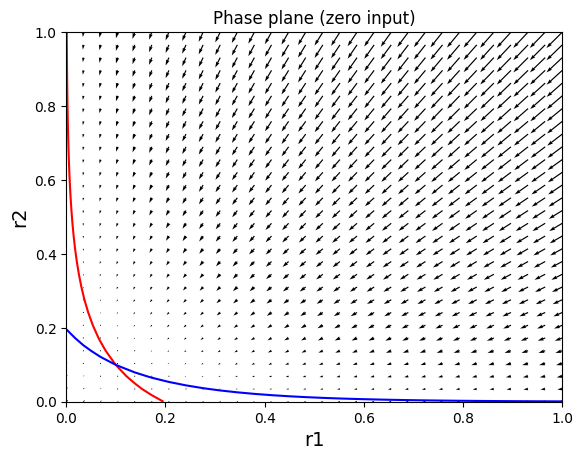

In [42]:
##Question a
W = np.array([[3, -5],
              [-5, 3]])
I_bg = -2.0

def g(x):
    return 1 / (1 + np.exp(-x))

def f(r, par=None):
    x = W @ r + I_bg
    return -r + g(x)

xs = np.linspace(0, 1, 30)  # because r in [0,1], gotten normalizeed by the g(x)
phaseplane_2D(f, None, xs_nullclines=xs, xs_quiver=xs, add_vectors=True, labels=['r1','r2'])
plt.title("Phase plane (zero input)")
plt.show()

#this graph confirms that the systems tends to go towards zero





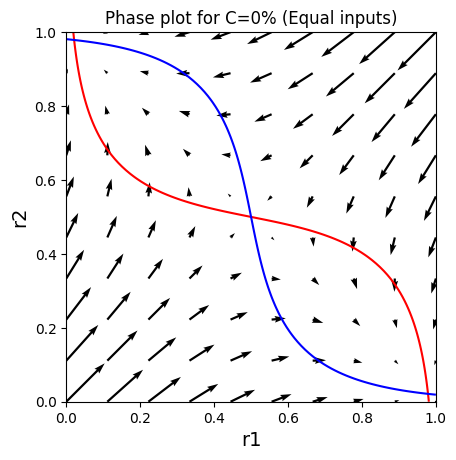